In [11]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 설치 (필요할 때만) + import + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요. polars가 이번 노트북의 새 도구입니다.
# !pip install numpy pandas polars matplotlib seaborn psutil -q

import os
import gc
import time
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)
print("polars :", pl.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy  : 2.4.6
pandas : 3.0.3
polars : 1.42.1


In [12]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 오늘 쓸 데이터를 한 번에 준비합니다.
# (이번에는 일부러 크게 만듭니다. 메모리 한계가 슬슬 보이도록.)
# ─────────────────────────────────────────────
np.random.seed(42)

DATA_DIR = Path("./moodumarket_big")
DATA_DIR.mkdir(exist_ok=True)

# 1) 고객(customers) — 5만 명
n_customers = 50_000
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(6)}" for i in range(1, n_customers + 1)],
    "age": np.clip(np.random.normal(35, 9, n_customers).round(), 14, 80).astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(
        ["서울", "경기", "부산", "인천", "대구", "광주", "대전", "기타"], n_customers
    ),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.7, 0.25, 0.05]),
})

# 2) 상품(products) — 1천 종
n_products = 1_000
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(5)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(["패션", "뷰티", "식품", "가전", "도서"], n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders) — 20만 건
n_orders = 200_000
orders = pd.DataFrame({
    "order_id": np.arange(1, n_orders + 1),
    "customer_id": np.random.choice(customers["customer_id"], n_orders),
    "product_id": np.random.choice(products["product_id"], n_orders),
    "quantity": np.random.choice([1, 1, 1, 2, 2, 3], n_orders),
    "amount": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_orders).astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.45, 0.55]),
    "order_date": pd.to_datetime("2025-01-01")
                  + pd.to_timedelta(np.random.randint(0, 120, n_orders), unit="D"),
})

# 4) 웹 로그(web_logs) — 50만 건 (오늘의 주인공)
n_logs = 500_000
web_logs = pd.DataFrame({
    "log_id": np.arange(1, n_logs + 1),
    "ts": pd.to_datetime("2025-04-01")
          + pd.to_timedelta(np.random.randint(0, 86400 * 30, n_logs), unit="s"),
    "user_id": np.random.choice(customers["customer_id"], n_logs),
    "session_id": np.random.randint(1, 80_000, n_logs),
    "page": np.random.choice(
        ["home", "list", "detail", "cart", "checkout", "mypage", "search"],
        n_logs,
        p=[0.30, 0.25, 0.20, 0.10, 0.05, 0.05, 0.05],
    ),
    "device": np.random.choice(["mobile", "desktop", "tablet"], n_logs, p=[0.70, 0.25, 0.05]),
    "status_code": np.random.choice([200, 200, 200, 200, 304, 404, 500], n_logs),
    "response_ms": np.clip(np.random.gamma(2.0, 80, n_logs), 5, 5000).round().astype(int),
    "bytes_sent": np.random.randint(500, 200_000, n_logs),
})

# CSV로 저장해두면 청크 처리·Polars 입출력 비교 시 같은 파일을 함께 씁니다.
orders_csv = DATA_DIR / "orders.csv"
logs_csv = DATA_DIR / "web_logs.csv"
orders.to_csv(orders_csv, index=False)
web_logs.to_csv(logs_csv, index=False)

print("모두마켓 데이터 생성 완료")
print(f"  customers : {customers.shape}")
print(f"  products  : {products.shape}")
print(f"  orders    : {orders.shape}  →  {orders_csv} ({orders_csv.stat().st_size/1024/1024:.1f} MB)")
print(f"  web_logs  : {web_logs.shape}  →  {logs_csv} ({logs_csv.stat().st_size/1024/1024:.1f} MB)")

모두마켓 데이터 생성 완료
  customers : (50000, 5)
  products  : (1000, 3)
  orders    : (200000, 7)  →  moodumarket_big/orders.csv (8.9 MB)
  web_logs  : (500000, 9)  →  moodumarket_big/web_logs.csv (32.3 MB)


In [13]:
# 예제 1: df.info(memory_usage='deep')로 자료형과 메모리를 함께 본다.
print("=== web_logs.info() — 자료형 + 메모리 ===")
web_logs.info(memory_usage="deep")

=== web_logs.info() — 자료형 + 메모리 ===
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   log_id       500000 non-null  int64         
 1   ts           500000 non-null  datetime64[us]
 2   user_id      500000 non-null  str           
 3   session_id   500000 non-null  int64         
 4   page         500000 non-null  str           
 5   device       500000 non-null  str           
 6   status_code  500000 non-null  int64         
 7   response_ms  500000 non-null  int64         
 8   bytes_sent   500000 non-null  int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 42.9 MB


In [14]:
# 예제 2: 컬럼별 메모리 사용량을 따져 보고 어디서 크게 먹는지 확인합니다.
mem = web_logs.memory_usage(deep=True).sort_values(ascending=False)
mem_mb = (mem / 1024 / 1024).round(2)

print("=== 컬럼별 메모리 (MB) ===")
print(mem_mb.to_string())
print(f"\n→ 총합: {mem_mb.sum():.2f} MB")

=== 컬럼별 메모리 (MB) ===
user_id        7.15
device         6.80
page           6.10
log_id         3.81
ts             3.81
session_id     3.81
status_code    3.81
response_ms    3.81
bytes_sent     3.81
Index          0.00

→ 총합: 42.91 MB


In [15]:
# 예제 3: psutil로 노트북 전체 메모리를 측정 — DataFrame 하나가 아닌 '지금 이 프로세스'.
try:
    import psutil
    proc = psutil.Process(os.getpid())
    rss_mb = proc.memory_info().rss / 1024 / 1024
    print(f"현재 노트북 프로세스 메모리 사용량(RSS): {rss_mb:.1f} MB")
    print("→ 위 web_logs 외에도 customers, orders, products 등이 함께 들어있어 더 큽니다.")
except ImportError:
    print("psutil 미설치 — `!pip install psutil` 로 설치하면 노트북 전체 메모리도 볼 수 있어요.")

현재 노트북 프로세스 메모리 사용량(RSS): 542.2 MB
→ 위 web_logs 외에도 customers, orders, products 등이 함께 들어있어 더 큽니다.


In [16]:
# 예제 4: '필터링이 사본을 만든다'는 사실을 RSS 변화로 확인합니다.
def rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

before = rss_mb()

# 사본을 일부러 5개 만든다 — 실제 분석에서도 이런 일이 줄줄이 일어납니다.
copies = []
for _ in range(5):
    copies.append(web_logs[web_logs["status_code"] == 200].copy())

after = rss_mb()
print(f"사본 만들기 전 RSS : {before:.1f} MB")
print(f"사본 5개 만든 후 RSS: {after:.1f} MB")
print(f"증가량               : {after - before:+.1f} MB")

# 청소: 사본 제거 → 가비지 컬렉션
del copies
gc.collect()
print(f"사본 제거 후 RSS    : {rss_mb():.1f} MB  (즉시 다 안 줄어도 정상입니다)")

사본 만들기 전 RSS : 542.2 MB
사본 5개 만든 후 RSS: 589.3 MB
증가량               : +47.1 MB
사본 제거 후 RSS    : 589.3 MB  (즉시 다 안 줄어도 정상입니다)


In [17]:
# 예제: 다이어트 전 — 현재 dtype과 메모리 확인
print("=== Before — 컬럼별 dtype과 메모리 ===")
print(web_logs.dtypes)
print()
print("메모리 합계:", web_logs.memory_usage(deep=True).sum() / 1024 / 1024, "MB")

=== Before — 컬럼별 dtype과 메모리 ===
log_id                  int64
ts             datetime64[us]
user_id                   str
session_id              int64
page                      str
device                    str
status_code             int64
response_ms             int64
bytes_sent              int64
dtype: object

메모리 합계: 42.940218925476074 MB


In [18]:
# 예제: 다이어트 후 — 작은 dtype과 category로 바꾸기
web_logs_small = web_logs.copy()

# 1) 정수 다이어트
web_logs_small["log_id"] = web_logs_small["log_id"].astype("int32")
web_logs_small["session_id"] = web_logs_small["session_id"].astype("int32")
web_logs_small["status_code"] = web_logs_small["status_code"].astype("int16")
web_logs_small["response_ms"] = web_logs_small["response_ms"].astype("int16")
web_logs_small["bytes_sent"] = web_logs_small["bytes_sent"].astype("int32")

# 2) 범주형 다이어트 (종류가 적은 문자열)
web_logs_small["page"] = web_logs_small["page"].astype("category")
web_logs_small["device"] = web_logs_small["device"].astype("category")

before_mb = web_logs.memory_usage(deep=True).sum() / 1024 / 1024
after_mb = web_logs_small.memory_usage(deep=True).sum() / 1024 / 1024
saved_pct = (1 - after_mb / before_mb) * 100

print(f"Before : {before_mb:6.2f} MB")
print(f"After  : {after_mb:6.2f} MB")
print(f"절감   : {saved_pct:5.1f}%  ({before_mb - after_mb:.2f} MB)")

Before :  42.94 MB
After  :  19.55 MB
절감   :  54.5%  (23.39 MB)


In [19]:
# 예제: 다이어트 후에도 분석 결과가 같은지 확인 — 핵심 검증.
before_result = web_logs.groupby("page", observed=True)["response_ms"].mean().sort_index()
after_result = web_logs_small.groupby("page", observed=True)["response_ms"].mean().sort_index()

# 두 시리즈가 (작은 부동소수점 오차 허용 범위에서) 같은지 확인
matches = np.allclose(before_result.values, after_result.values, atol=1e-6)
print("두 결과가 같은가:", matches)
print()
print("=== Before (int16 변환 전) ===")
print(before_result.round(2))
print("\n=== After (int16 변환 후) ===")
print(after_result.round(2))

두 결과가 같은가: True

=== Before (int16 변환 전) ===
page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64

=== After (int16 변환 후) ===
page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64


In [20]:
# 예제: read_csv 단계부터 dtype을 지정해 처음부터 작게 읽기
dtype_map = {
    "log_id": "int32",
    "user_id": "string",       # 그대로 문자열로 두되 pandas의 string 타입으로
    "session_id": "int32",
    "page": "category",
    "device": "category",
    "status_code": "int16",
    "response_ms": "int16",
    "bytes_sent": "int32",
}

t0 = time.perf_counter()
web_logs_compact = pd.read_csv(
    logs_csv,
    dtype=dtype_map,
    parse_dates=["ts"],
)
elapsed = time.perf_counter() - t0
mem_mb = web_logs_compact.memory_usage(deep=True).sum() / 1024 / 1024

print(f"읽는 시간 : {elapsed:5.2f} 초")
print(f"메모리   : {mem_mb:5.2f} MB")
print()
print(web_logs_compact.dtypes)

읽는 시간 :  0.59 초
메모리   : 19.55 MB

log_id                  int32
ts             datetime64[us]
user_id                string
session_id              int32
page                 category
device               category
status_code             int16
response_ms             int16
bytes_sent              int32
dtype: object


In [21]:
# 1. orders 현재 메모리 측정
before_mb = orders.memory_usage(deep=True).sum() / 1024 / 1024
print(f"변환 전 메모리: {before_mb:.2f} MB")
print(orders.dtypes)
print()

# 고유값 비율 먼저 확인 (category로 바꿀지 판단 근거)
print("customer_id 고유값 비율:", orders["customer_id"].nunique() / len(orders))
print("product_id 고유값 비율 :", orders["product_id"].nunique() / len(orders))
print()

# 2. dtype 줄여서 orders_small 만들기
orders_small = orders.copy()

orders_small["quantity"] = orders_small["quantity"].astype("int16")
orders_small["channel"] = orders_small["channel"].astype("category")
orders_small["customer_id"] = orders_small["customer_id"].astype("category")
orders_small["product_id"] = orders_small["product_id"].astype("category")

# 3. 줄인 뒤 메모리와 절감률 출력
after_mb = orders_small.memory_usage(deep=True).sum() / 1024 / 1024
saved_pct = (1 - after_mb / before_mb) * 100

print(f"변환 후 메모리: {after_mb:.2f} MB")
print(f"절감률       : {saved_pct:.1f}%  ({before_mb - after_mb:.2f} MB 절약)")


변환 전 메모리: 13.73 MB
order_id                int64
customer_id               str
product_id                str
quantity                int64
amount                float64
channel                   str
order_date     datetime64[us]
dtype: object

customer_id 고유값 비율: 0.24553
product_id 고유값 비율 : 0.005

변환 후 메모리: 7.02 MB
절감률       : 48.9%  (6.72 MB 절약)


In [22]:
# 예제 1: (A) 통째로 — 페이지별 평균 응답 시간 계산 + 메모리 측정
def rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024

# 통째로 읽고 집계
gc.collect()
before = rss_mb()
t0 = time.perf_counter()

full = pd.read_csv(logs_csv, parse_dates=["ts"])
result_full = full.groupby("page")["response_ms"].mean().round(2)

elapsed_full = time.perf_counter() - t0
peak_full = rss_mb() - before

del full
gc.collect()

print("=== 통째로 읽기 ===")
print(f"소요 시간: {elapsed_full:5.2f} 초")
print(f"메모리 증가량(피크 근사): {peak_full:.1f} MB")
print()
print(result_full)

=== 통째로 읽기 ===
소요 시간:  0.40 초
메모리 증가량(피크 근사): 37.8 MB

page
cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
Name: response_ms, dtype: float64


In [23]:
# 예제 2: (B) 청크로 — 같은 결과를 청크 단위로 계산하고 합치기
# 각 청크에서 (page별 합계, 개수)를 모은 다음 마지막에 합 ÷ 개수.

gc.collect()
before = rss_mb()
t0 = time.perf_counter()

CHUNK = 50_000
sum_per_page = {}
cnt_per_page = {}

for chunk in pd.read_csv(logs_csv, chunksize=CHUNK,
                          dtype={"page": "category", "device": "category"},
                          parse_dates=["ts"]):
    grouped = chunk.groupby("page", observed=True)["response_ms"].agg(["sum", "count"])
    for page, row in grouped.iterrows():
        sum_per_page[page] = sum_per_page.get(page, 0) + row["sum"]
        cnt_per_page[page] = cnt_per_page.get(page, 0) + row["count"]

# reduce: 합 ÷ 개수
result_chunk = pd.Series({
    page: sum_per_page[page] / cnt_per_page[page]
    for page in sum_per_page
}).round(2).sort_index()

elapsed_chunk = time.perf_counter() - t0
peak_chunk = rss_mb() - before

print("=== 청크로 읽기 ===")
print(f"청크 크기: {CHUNK:,}행")
print(f"소요 시간: {elapsed_chunk:5.2f} 초")
print(f"메모리 증가량(피크 근사): {peak_chunk:.1f} MB")
print()
print(result_chunk)

=== 청크로 읽기 ===
청크 크기: 50,000행
소요 시간:  0.52 초
메모리 증가량(피크 근사): 2.0 MB

cart        160.27
checkout    159.94
detail      160.03
home        159.86
list        159.97
mypage      158.34
search      160.42
dtype: float64


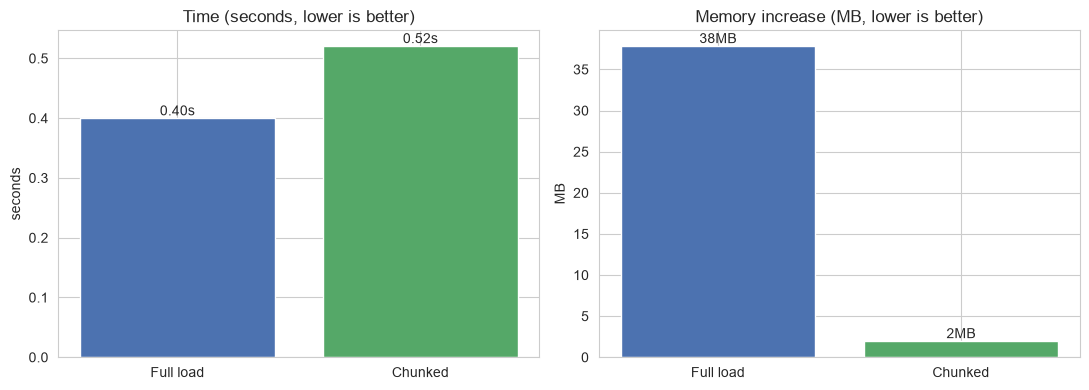

In [24]:
# ─────────────────────────────────────────────
# [도식] 통째로 vs 청크 — 시간/메모리 막대그래프
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

methods = ["Full load", "Chunked"]
times = [elapsed_full, elapsed_chunk]
peaks = [peak_full, peak_chunk]

axes[0].bar(methods, times, color=["#4C72B0", "#55A868"])
axes[0].set_title("Time (seconds, lower is better)")
axes[0].set_ylabel("seconds")
for i, v in enumerate(times):
    axes[0].text(i, v, f"{v:.2f}s", ha="center", va="bottom")

axes[1].bar(methods, peaks, color=["#4C72B0", "#55A868"])
axes[1].set_title("Memory increase (MB, lower is better)")
axes[1].set_ylabel("MB")
for i, v in enumerate(peaks):
    axes[1].text(i, v, f"{v:.0f}MB", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [25]:
import matplotlib.pyplot as plt


In [26]:
# 예제 1: Polars로 CSV 읽기 — pl.read_csv
t0 = time.perf_counter()
logs_pl = pl.read_csv(logs_csv, try_parse_dates=True)
elapsed_pl = time.perf_counter() - t0

# pandas와 같은 작업: 시간 측정용
t0 = time.perf_counter()
logs_pd = pd.read_csv(logs_csv, parse_dates=["ts"])
elapsed_pd = time.perf_counter() - t0

print(f"Polars pl.read_csv : {elapsed_pl:.2f} 초   shape = {logs_pl.shape}")
print(f"pandas pd.read_csv : {elapsed_pd:.2f} 초   shape = {logs_pd.shape}")
print()
print("=== Polars head ===")
print(logs_pl.head())

Polars pl.read_csv : 0.14 초   shape = (500000, 9)
pandas pd.read_csv : 0.44 초   shape = (500000, 9)

=== Polars head ===
shape: (5, 9)
┌────────┬─────────────┬─────────┬────────────┬───┬─────────┬────────────┬────────────┬────────────┐
│ log_id ┆ ts          ┆ user_id ┆ session_id ┆ … ┆ device  ┆ status_cod ┆ response_m ┆ bytes_sent │
│ ---    ┆ ---         ┆ ---     ┆ ---        ┆   ┆ ---     ┆ e          ┆ s          ┆ ---        │
│ i64    ┆ datetime[μs ┆ str     ┆ i64        ┆   ┆ str     ┆ ---        ┆ ---        ┆ i64        │
│        ┆ ]           ┆         ┆            ┆   ┆         ┆ i64        ┆ i64        ┆            │
╞════════╪═════════════╪═════════╪════════════╪═══╪═════════╪════════════╪════════════╪════════════╡
│ 1      ┆ 2025-04-21  ┆ C044419 ┆ 2436       ┆ … ┆ mobile  ┆ 200        ┆ 277        ┆ 84795      │
│        ┆ 15:33:35    ┆         ┆            ┆   ┆         ┆            ┆            ┆            │
│ 2      ┆ 2025-04-14  ┆ C011729 ┆ 10149      ┆ … ┆ mobil

In [27]:
# 예제 2: 같은 작업을 Polars로 — 페이지별 평균 응답 시간
t0 = time.perf_counter()
result_pl = (
    logs_pl
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .sort("page")
)
elapsed_pl = time.perf_counter() - t0

t0 = time.perf_counter()
result_pd = logs_pd.groupby("page")["response_ms"].mean().sort_index().round(2)
elapsed_pd = time.perf_counter() - t0

print(f"Polars group_by + mean : {elapsed_pl*1000:.1f} ms")
print(f"pandas groupby  + mean : {elapsed_pd*1000:.1f} ms")
print()
print("=== Polars 결과 ===")
print(result_pl)

Polars group_by + mean : 86.3 ms
pandas groupby  + mean : 9.0 ms

=== Polars 결과 ===
shape: (7, 2)
┌──────────┬────────────┐
│ page     ┆ avg_ms     │
│ ---      ┆ ---        │
│ str      ┆ f64        │
╞══════════╪════════════╡
│ cart     ┆ 160.27064  │
│ checkout ┆ 159.938837 │
│ detail   ┆ 160.034422 │
│ home     ┆ 159.862077 │
│ list     ┆ 159.966265 │
│ mypage   ┆ 158.343924 │
│ search   ┆ 160.420165 │
└──────────┴────────────┘


In [28]:
result_device = (
    logs_pl
    .group_by("device")
    .agg(pl.col("bytes_sent").sum().alias("total_bytes"))
    .sort("device")
)

print(result_device)

shape: (3, 2)
┌─────────┬─────────────┐
│ device  ┆ total_bytes │
│ ---     ┆ ---         │
│ str     ┆ i64         │
╞═════════╪═════════════╡
│ desktop ┆ 12616794831 │
│ mobile  ┆ 35107613460 │
│ tablet  ┆ 2467104056  │
└─────────┴─────────────┘


In [29]:
import time


t0 = time.perf_counter()
result_eager = (
    pl.read_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .sort("page")
)
elapsed_eager = time.perf_counter() - t0


t0 = time.perf_counter()
result_lazy = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .sort("page")
    .collect()
)
elapsed_lazy = time.perf_counter() - t0

print(f"eager: {elapsed_eager*1000:.1f} ms")
print(f"lazy : {elapsed_lazy*1000:.1f} ms")

eager: 146.8 ms
lazy : 40.5 ms


In [30]:
# 모범 답안 — 직접 해본 다음 비교하세요.
ans = (
    logs_pl
    .group_by("device")
    .agg(pl.col("bytes_sent").sum().alias("total_bytes"))
    .sort("total_bytes", descending=True)
)
print(ans)

shape: (3, 2)
┌─────────┬─────────────┐
│ device  ┆ total_bytes │
│ ---     ┆ ---         │
│ str     ┆ i64         │
╞═════════╪═════════════╡
│ mobile  ┆ 35107613460 │
│ desktop ┆ 12616794831 │
│ tablet  ┆ 2467104056  │
└─────────┴─────────────┘


In [31]:
# 예제 1: eager 방식 — 한 줄씩 즉시 실행
t0 = time.perf_counter()
result_eager = (
    pl.read_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg([
        pl.col("response_ms").mean().alias("avg_ms"),
        pl.len().alias("n_rows"),
    ])
    .sort("avg_ms")
)
elapsed_eager = time.perf_counter() - t0

print(f"Eager  : {elapsed_eager*1000:6.1f} ms")
print(result_eager)

Eager  :  104.2 ms
shape: (7, 3)
┌──────────┬────────────┬────────┐
│ page     ┆ avg_ms     ┆ n_rows │
│ ---      ┆ ---        ┆ ---    │
│ str      ┆ f64        ┆ u32    │
╞══════════╪════════════╪════════╡
│ mypage   ┆ 158.164001 ┆ 14378  │
│ list     ┆ 159.704364 ┆ 71260  │
│ home     ┆ 159.858675 ┆ 85689  │
│ cart     ┆ 160.040313 ┆ 28527  │
│ detail   ┆ 160.16073  ┆ 57500  │
│ checkout ┆ 161.431966 ┆ 14309  │
│ search   ┆ 161.780443 ┆ 14133  │
└──────────┴────────────┴────────┘


In [32]:
# 예제 2: lazy 방식 — scan_csv로 계획만, 마지막에 collect()
t0 = time.perf_counter()
result_lazy = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg([
        pl.col("response_ms").mean().alias("avg_ms"),
        pl.len().alias("n_rows"),
    ])
    .sort("avg_ms")
    .collect()
)
elapsed_lazy = time.perf_counter() - t0

print(f"Lazy   : {elapsed_lazy*1000:6.1f} ms")
print(result_lazy)

Lazy   :   24.2 ms
shape: (7, 3)
┌──────────┬────────────┬────────┐
│ page     ┆ avg_ms     ┆ n_rows │
│ ---      ┆ ---        ┆ ---    │
│ str      ┆ f64        ┆ u32    │
╞══════════╪════════════╪════════╡
│ mypage   ┆ 158.164001 ┆ 14378  │
│ list     ┆ 159.704364 ┆ 71260  │
│ home     ┆ 159.858675 ┆ 85689  │
│ cart     ┆ 160.040313 ┆ 28527  │
│ detail   ┆ 160.16073  ┆ 57500  │
│ checkout ┆ 161.431966 ┆ 14309  │
│ search   ┆ 161.780443 ┆ 14133  │
└──────────┴────────────┴────────┘


In [33]:
# 예제 3: Polars가 어떤 계획을 세웠는지 확인 — .explain()
plan = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") == 200)
    .group_by("page")
    .agg(pl.col("response_ms").mean().alias("avg_ms"))
    .explain()
)
print(plan)

AGGREGATE[maintain_order: false]
  [col("response_ms").mean().alias("avg_ms")] BY [col("page")]
  FROM
  simple π 2/2 ["page", "response_ms"]
    Csv SCAN [moodumarket_big/web_logs.csv]
    PROJECT 3/9 COLUMNS
    SELECTION: [(col("status_code")) == (200)]
    ESTIMATED ROWS: 537956


In [34]:
result_errors = (
    pl.scan_csv(logs_csv, try_parse_dates=True)
    .filter(pl.col("status_code") >= 400)
    .group_by("page")
    .agg(pl.len().alias("error_count"))
    .sort("error_count", descending=True)
    .collect()
)

print(result_errors)

shape: (7, 2)
┌──────────┬─────────────┐
│ page     ┆ error_count │
│ ---      ┆ ---         │
│ str      ┆ u32         │
╞══════════╪═════════════╡
│ home     ┆ 42898       │
│ list     ┆ 35593       │
│ detail   ┆ 28298       │
│ cart     ┆ 14360       │
│ search   ┆ 7256        │
│ mypage   ┆ 7244        │
│ checkout ┆ 7108        │
└──────────┴─────────────┘


In [35]:
# 벤치마크 유틸 — 같은 작업을 N회 돌려 평균 시간을 측정
def benchmark(label, func, n=3):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        func()
        times.append(time.perf_counter() - t0)
    avg_ms = sum(times) / n * 1000
    print(f"{label:24s}: {avg_ms:7.1f} ms   (n={n}, min={min(times)*1000:.1f}ms)")
    return avg_ms

# 측정 대상 함수들 — Q1: 페이지별 평균 응답 시간
def q1_pandas():
    return (
        pd.read_csv(logs_csv)
        .groupby("page")["response_ms"].mean()
    )

def q1_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").mean())
    )

def q1_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").mean())
        .collect()
    )

print("=== Q1: 페이지별 평균 응답 시간 ===")
q1_pd = benchmark("pandas",        q1_pandas)
q1_pe = benchmark("polars (eager)", q1_polars_eager)
q1_pl = benchmark("polars (lazy)",  q1_polars_lazy)

=== Q1: 페이지별 평균 응답 시간 ===
pandas                  :   335.9 ms   (n=3, min=325.1ms)
polars (eager)          :    16.0 ms   (n=3, min=14.5ms)
polars (lazy)           :    16.7 ms   (n=3, min=15.8ms)


In [36]:
# Q2: 디바이스별 bytes_sent 합계
def q2_pandas():
    return pd.read_csv(logs_csv).groupby("device")["bytes_sent"].sum()

def q2_polars_eager():
    return pl.read_csv(logs_csv).group_by("device").agg(pl.col("bytes_sent").sum())

def q2_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("device")
        .agg(pl.col("bytes_sent").sum())
        .collect()
    )

print("=== Q2: 디바이스별 bytes_sent 합계 ===")
q2_pd = benchmark("pandas",        q2_pandas)
q2_pe = benchmark("polars (eager)", q2_polars_eager)
q2_pl = benchmark("polars (lazy)",  q2_polars_lazy)

=== Q2: 디바이스별 bytes_sent 합계 ===
pandas                  :   340.0 ms   (n=3, min=317.4ms)
polars (eager)          :    15.2 ms   (n=3, min=14.1ms)
polars (lazy)           :    20.0 ms   (n=3, min=19.3ms)


In [37]:
# Q3: status_code >= 400 페이지별 에러 수 (필터 + 집계 → pushdown 유리)
def q3_pandas():
    df = pd.read_csv(logs_csv)
    return df[df["status_code"] >= 400].groupby("page").size()

def q3_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len())
    )

def q3_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len())
        .collect()
    )

print("=== Q3: status_code>=400 페이지별 에러 수 ===")
q3_pd = benchmark("pandas",        q3_pandas)
q3_pe = benchmark("polars (eager)", q3_polars_eager)
q3_pl = benchmark("polars (lazy)",  q3_polars_lazy)

=== Q3: status_code>=400 페이지별 에러 수 ===
pandas                  :   343.1 ms   (n=3, min=326.0ms)
polars (eager)          :    20.6 ms   (n=3, min=17.5ms)
polars (lazy)           :    18.1 ms   (n=3, min=15.6ms)


In [38]:
# Q4: 페이지별 응답 시간의 중앙값 (정렬 필요, pandas 약점)
def q4_pandas():
    return pd.read_csv(logs_csv).groupby("page")["response_ms"].median()

def q4_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").median())
    )

def q4_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .group_by("page")
        .agg(pl.col("response_ms").median())
        .collect()
    )

print("=== Q4: 페이지별 응답 시간 중앙값 ===")
q4_pd = benchmark("pandas",        q4_pandas)
q4_pe = benchmark("polars (eager)", q4_polars_eager)
q4_pl = benchmark("polars (lazy)",  q4_polars_lazy)

=== Q4: 페이지별 응답 시간 중앙값 ===
pandas                  :   331.7 ms   (n=3, min=320.5ms)
polars (eager)          :    21.0 ms   (n=3, min=17.8ms)
polars (lazy)           :    18.7 ms   (n=3, min=16.6ms)


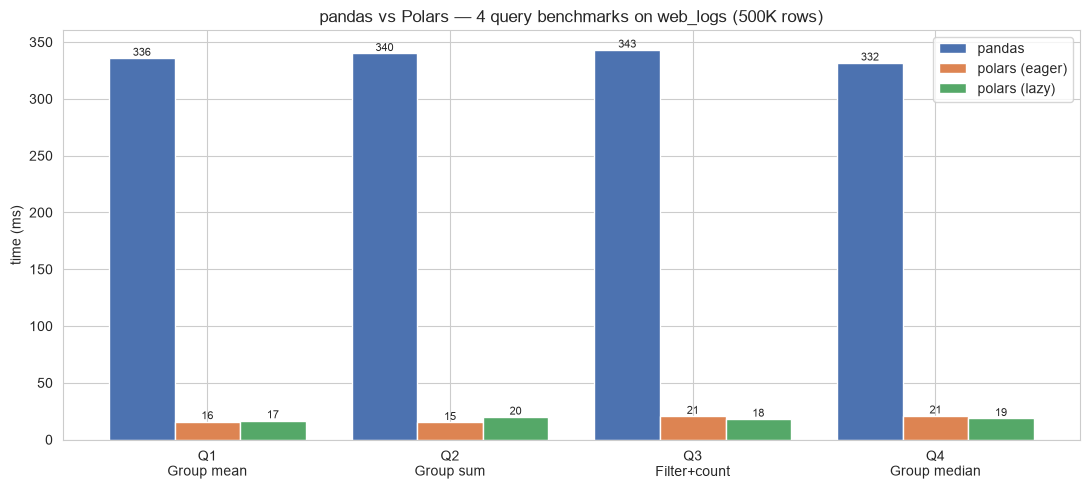

In [39]:
# ─────────────────────────────────────────────
# [도식] 4개 쿼리 × 3개 도구 비교 막대그래프
# ─────────────────────────────────────────────
queries = ["Q1\nGroup mean", "Q2\nGroup sum", "Q3\nFilter+count", "Q4\nGroup median"]
pd_times = [q1_pd, q2_pd, q3_pd, q4_pd]
pe_times = [q1_pe, q2_pe, q3_pe, q4_pe]
pl_times = [q1_pl, q2_pl, q3_pl, q4_pl]

x = np.arange(len(queries))
width = 0.27

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, pd_times, width, label="pandas", color="#4C72B0")
ax.bar(x,         pe_times, width, label="polars (eager)", color="#DD8452")
ax.bar(x + width, pl_times, width, label="polars (lazy)", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(queries)
ax.set_ylabel("time (ms)")
ax.set_title("pandas vs Polars — 4 query benchmarks on web_logs (500K rows)")
ax.legend()

# 각 막대 위에 숫자 표기
for arr, off in [(pd_times, -width), (pe_times, 0), (pl_times, width)]:
    for i, v in enumerate(arr):
        ax.text(i + off, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [40]:
# Q5: channel='mobile' & status_code==200 → page별 평균 bytes_sent

def q5_pandas():
    df = pd.read_csv(logs_csv)
    filtered = df[(df["device"] == "mobile") & (df["status_code"] == 200)]
    return filtered.groupby("page")["bytes_sent"].mean()

def q5_polars_eager():
    return (
        pl.read_csv(logs_csv)
        .filter((pl.col("device") == "mobile") & (pl.col("status_code") == 200))
        .group_by("page")
        .agg(pl.col("bytes_sent").mean())
    )

def q5_polars_lazy():
    return (
        pl.scan_csv(logs_csv)
        .filter((pl.col("device") == "mobile") & (pl.col("status_code") == 200))
        .group_by("page")
        .agg(pl.col("bytes_sent").mean())
        .collect()
    )

print("=== Q5: mobile & status==200 → page별 평균 bytes_sent ===")
q5_pd = benchmark("pandas",         q5_pandas)
q5_pe = benchmark("polars (eager)", q5_polars_eager)
q5_pl = benchmark("polars (lazy)",  q5_polars_lazy)

=== Q5: mobile & status==200 → page별 평균 bytes_sent ===
pandas                  :   354.1 ms   (n=3, min=336.7ms)
polars (eager)          :    22.1 ms   (n=3, min=18.7ms)
polars (lazy)           :    22.5 ms   (n=3, min=21.3ms)


In [41]:
# 예제: 의사결정 함수 — 파일 크기와 요구사항으로 도구를 추천
def recommend_tool(file_path, *, need_streaming=False, team_uses_polars=False):
    # 파일 크기와 환경 정보로 1차 도구를 추천합니다.
    file_path = Path(file_path)
    if not file_path.exists():
        return "파일이 존재하지 않습니다."
    size_mb = file_path.stat().st_size / 1024 / 1024

    # 행 수는 직접 모르지만 파일 크기로 어림잡습니다 (csv 기준)
    if size_mb < 10:
        return f"[{size_mb:.0f}MB] pandas — 굳이 바꿀 필요 없습니다."
    elif size_mb < 100:
        return f"[{size_mb:.0f}MB] pandas + dtype 최적화 — 다이어트만으로 충분."
    elif size_mb < 1000:
        tool = "Polars (lazy)" if team_uses_polars or need_streaming else "Polars (eager)"
        return f"[{size_mb:.0f}MB] {tool} — 속도 차이가 체감되는 구간."
    else:
        return f"[{size_mb:.0f}MB] Polars lazy + Parquet — 단일 머신 한계 근처."

# 우리 데이터에 적용
print(recommend_tool(orders_csv))
print(recommend_tool(logs_csv))
print(recommend_tool(logs_csv, team_uses_polars=True))

[9MB] pandas — 굳이 바꿀 필요 없습니다.
[32MB] pandas + dtype 최적화 — 다이어트만으로 충분.
[32MB] pandas + dtype 최적화 — 다이어트만으로 충분.


In [42]:
# A: pandas — orders_csv(9MB)는 작아서 새 도구 도입 비용이 무의미. 그냥 pandas로 충분.
# B: pandas + dtype 최적화 — logs_csv(32MB)는 100MB 미만 구간이라 Polars 전환보다 dtype 다운캐스팅이 비용 대비 효율적.
# C: (버그) — logs_csv에 team_uses_polars=True 줬는데도 B랑 똑같이 "pandas + dtype"이 나옴.

In [44]:
# 시나리오 1 — pandas + dtype 최적화 (전체 분석을 한 함수로 묶음)
def analyze_pandas_optimized(csv_path):
    dtype_map = {
        "log_id": "int32", "session_id": "int32",
        "page": "category", "device": "category",
        "status_code": "int16", "response_ms": "int16", "bytes_sent": "int32",
    }
    df = pd.read_csv(csv_path, dtype=dtype_map, parse_dates=["ts"])

    # (1) 페이지별 응답 시간 분포 — 평균·중앙값·표준편차
    by_page = df.groupby("page", observed=True)["response_ms"].agg(
        ["mean", "median", "std"]
    ).round(2)

    # (2) 디바이스별 트래픽 점유율 — 총 bytes_sent의 디바이스별 비율
    dev_total = df.groupby("device", observed=True)["bytes_sent"].sum()
    dev_share = (dev_total / dev_total.sum() * 100).round(1).rename("share_pct")

    # (3) 에러 발생 패턴 — status_code 400+ 의 페이지별 카운트
    err_count = (df[df["status_code"] >= 400]
                 .groupby("page", observed=True).size()
                 .rename("n_errors").sort_values(ascending=False))

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pd = analyze_pandas_optimized(logs_csv)
elapsed_pd_full = time.perf_counter() - t0
peak_pd_full = rss_mb() - before

print(f"[pandas + dtype] 소요 시간: {elapsed_pd_full:.2f}초, 메모리 증가량: {peak_pd_full:.1f} MB\n")
print("(1) 페이지별 응답 시간"); print(res_pd["by_page"]); print()
print("(2) 디바이스별 트래픽 점유율(%)"); print(res_pd["dev_share"]); print()
print("(3) 에러 카운트"); print(res_pd["err_count"])

[pandas + dtype] 소요 시간: 0.37초, 메모리 증가량: 2.1 MB

(1) 페이지별 응답 시간
            mean  median     std
page                            
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.82

(2) 디바이스별 트래픽 점유율(%)
device
desktop    25.1
mobile     69.9
tablet      4.9
Name: share_pct, dtype: float64

(3) 에러 카운트
page
home        42898
list        35593
detail      28298
cart        14360
search       7256
mypage       7244
checkout     7108
Name: n_errors, dtype: int64


In [45]:
# 시나리오 2 — 청크 처리 (같은 분석을 50K 청크로)
def analyze_chunked(csv_path, chunksize=50_000):
    # 누적 컨테이너
    sum_ms = {}; cnt_ms = {}; ms_lists = {}
    dev_bytes = {}; err_by_page = {}

    for chunk in pd.read_csv(csv_path, chunksize=chunksize,
                              dtype={"page": "category", "device": "category",
                                     "status_code": "int16", "response_ms": "int16"},
                              parse_dates=["ts"]):
        # 페이지별 합계·개수 (평균/표준편차 재계산용으로 모든 값 모음)
        for page, g in chunk.groupby("page", observed=True):
            sum_ms[page] = sum_ms.get(page, 0) + g["response_ms"].sum()
            cnt_ms[page] = cnt_ms.get(page, 0) + g["response_ms"].count()
            ms_lists.setdefault(page, []).append(g["response_ms"].values)

        # 디바이스별 bytes 합
        for dev, g in chunk.groupby("device", observed=True):
            dev_bytes[dev] = dev_bytes.get(dev, 0) + g["bytes_sent"].sum()

        # 에러 페이지별 카운트
        errs = chunk[chunk["status_code"] >= 400].groupby("page", observed=True).size()
        for page, n in errs.items():
            err_by_page[page] = err_by_page.get(page, 0) + n

    # reduce — 페이지별 통계 (mean/median/std)
    by_page = pd.DataFrame({
        page: {
            "mean":   sum_ms[page] / cnt_ms[page],
            "median": float(np.median(np.concatenate(ms_lists[page]))),
            "std":    float(np.concatenate(ms_lists[page]).std()),
        } for page in sum_ms
    }).T.round(2)

    dev_total = pd.Series(dev_bytes)
    dev_share = (dev_total / dev_total.sum() * 100).round(1).rename("share_pct")
    err_count = pd.Series(err_by_page).sort_values(ascending=False).rename("n_errors")

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_chunk = analyze_chunked(logs_csv)
elapsed_chunk_full = time.perf_counter() - t0
peak_chunk_full = rss_mb() - before

print(f"[chunked] 소요 시간: {elapsed_chunk_full:.2f}초, 메모리 증가량: {peak_chunk_full:.1f} MB")
print("by_page (chunked):"); print(res_chunk["by_page"].sort_index())

[chunked] 소요 시간: 0.51초, 메모리 증가량: 0.1 MB
by_page (chunked):
            mean  median     std
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.81


In [46]:
import sys
print(sys.executable)
import pyarrow
print(pyarrow.__version__)

/opt/anaconda3/envs/myenv/bin/python
25.0.0


In [47]:
# 시나리오 3 — Polars lazy (한 파이프라인)
def analyze_polars_lazy(csv_path):
    lf = pl.scan_csv(csv_path, try_parse_dates=True)

    # (1) 페이지별 응답 시간 — mean/median/std 한 번에
    by_page_lf = lf.group_by("page").agg([
        pl.col("response_ms").mean().alias("mean"),
        pl.col("response_ms").median().alias("median"),
        pl.col("response_ms").std().alias("std"),
    ]).sort("page")

    # (2) 디바이스별 점유율
    dev_lf = lf.group_by("device").agg(
        pl.col("bytes_sent").sum().alias("total_bytes")
    )
    # 점유율은 collect 후에 계산 (전체 합 필요)

    # (3) 에러 페이지별 카운트 — Predicate pushdown 적용 예상
    err_lf = (
        lf.filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len().alias("n_errors"))
        .sort("n_errors", descending=True)
    )

    by_page = by_page_lf.collect().to_pandas().set_index("page").round(2)
    dev_tot = dev_lf.collect().to_pandas().set_index("device")["total_bytes"]
    dev_share = (dev_tot / dev_tot.sum() * 100).round(1).rename("share_pct")
    err_count = err_lf.collect().to_pandas().set_index("page")["n_errors"]

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pl = analyze_polars_lazy(logs_csv)
elapsed_pl_full = time.perf_counter() - t0
peak_pl_full = rss_mb() - before

print(f"[Polars lazy] 소요 시간: {elapsed_pl_full:.2f}초, 메모리 증가량: {peak_pl_full:.1f} MB\n")
print("by_page (polars):"); print(res_pl["by_page"].sort_index())

[Polars lazy] 소요 시간: 0.12초, 메모리 증가량: 24.7 MB

by_page (polars):
            mean  median     std
page                            
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.82


In [48]:
def analyze_polars_lazy(csv_path):
    lf = pl.scan_csv(csv_path, try_parse_dates=True)

    # (1) 페이지별 응답 시간 — mean/median/std 한 번에
    by_page = (
        lf.group_by("page").agg([
            pl.col("response_ms").mean().alias("mean"),
            pl.col("response_ms").median().alias("median"),
            pl.col("response_ms").std().alias("std"),
        ])
        .sort("page")
        .collect()
    )

    # (2) 디바이스별 점유율
    dev_lf = lf.group_by("device").agg(
        pl.col("bytes_sent").sum().alias("total_bytes")
    ).collect()
    total = dev_lf["total_bytes"].sum()
    dev_share = dev_lf.with_columns(
        (pl.col("total_bytes") / total * 100).round(1).alias("share_pct")
    )

    # (3) 에러 페이지별 카운트
    err_count = (
        lf.filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len().alias("n_errors"))
        .sort("n_errors", descending=True)
        .collect()
    )

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}


gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pl = analyze_polars_lazy(logs_csv)
elapsed_pl_full = time.perf_counter() - t0
peak_pl_full = rss_mb() - before

print(f"[Polars lazy] 소요 시간: {elapsed_pl_full:.2f}초, 메모리 증가량: {peak_pl_full:.1f} MB\n")
print("by_page (polars):"); print(res_pl["by_page"])
print("dev_share (polars):"); print(res_pl["dev_share"])
print("err_count (polars):"); print(res_pl["err_count"])

[Polars lazy] 소요 시간: 0.08초, 메모리 증가량: -20.2 MB

by_page (polars):
shape: (7, 4)
┌──────────┬────────────┬────────┬────────────┐
│ page     ┆ mean       ┆ median ┆ std        │
│ ---      ┆ ---        ┆ ---    ┆ ---        │
│ str      ┆ f64        ┆ f64    ┆ f64        │
╞══════════╪════════════╪════════╪════════════╡
│ cart     ┆ 160.27064  ┆ 134.0  ┆ 113.133394 │
│ checkout ┆ 159.938837 ┆ 134.0  ┆ 112.94436  │
│ detail   ┆ 160.034422 ┆ 135.0  ┆ 112.999145 │
│ home     ┆ 159.862077 ┆ 134.0  ┆ 112.785776 │
│ list     ┆ 159.966265 ┆ 134.0  ┆ 112.885994 │
│ mypage   ┆ 158.343924 ┆ 132.0  ┆ 111.654469 │
│ search   ┆ 160.420165 ┆ 134.0  ┆ 113.81643  │
└──────────┴────────────┴────────┴────────────┘
dev_share (polars):
shape: (3, 3)
┌─────────┬─────────────┬───────────┐
│ device  ┆ total_bytes ┆ share_pct │
│ ---     ┆ ---         ┆ ---       │
│ str     ┆ i64         ┆ f64       │
╞═════════╪═════════════╪═══════════╡
│ tablet  ┆ 2467104056  ┆ 4.9       │
│ desktop ┆ 12616794831 ┆ 25.1     

In [49]:
# 시나리오 3 — Polars lazy (한 파이프라인)
def analyze_polars_lazy(csv_path):
    lf = pl.scan_csv(csv_path, try_parse_dates=True)

    # (1) 페이지별 응답 시간 — mean/median/std 한 번에
    by_page_lf = lf.group_by("page").agg([
        pl.col("response_ms").mean().alias("mean"),
        pl.col("response_ms").median().alias("median"),
        pl.col("response_ms").std().alias("std"),
    ]).sort("page")

    # (2) 디바이스별 점유율
    dev_lf = lf.group_by("device").agg(
        pl.col("bytes_sent").sum().alias("total_bytes")
    )
    # 점유율은 collect 후에 계산 (전체 합 필요)


    err_lf = (
        lf.filter(pl.col("status_code") >= 400)
        .group_by("page")
        .agg(pl.len().alias("n_errors"))
        .sort("n_errors", descending=True)
    )

    by_page = by_page_lf.collect().to_pandas().set_index("page").round(2)
    dev_tot = dev_lf.collect().to_pandas().set_index("device")["total_bytes"]
    dev_share = (dev_tot / dev_tot.sum() * 100).round(1).rename("share_pct")
    err_count = err_lf.collect().to_pandas().set_index("page")["n_errors"]

    return {"by_page": by_page, "dev_share": dev_share, "err_count": err_count}

gc.collect()
before = rss_mb()
t0 = time.perf_counter()
res_pl = analyze_polars_lazy(logs_csv)
elapsed_pl_full = time.perf_counter() - t0
peak_pl_full = rss_mb() - before

print(f"[Polars lazy] 소요 시간: {elapsed_pl_full:.2f}초, 메모리 증가량: {peak_pl_full:.1f} MB\n")
print("by_page (polars):"); print(res_pl["by_page"].sort_index())

[Polars lazy] 소요 시간: 0.07초, 메모리 증가량: -5.7 MB

by_page (polars):
            mean  median     std
page                            
cart      160.27   134.0  113.13
checkout  159.94   134.0  112.94
detail    160.03   135.0  113.00
home      159.86   134.0  112.79
list      159.97   134.0  112.89
mypage    158.34   132.0  111.65
search    160.42   134.0  113.82


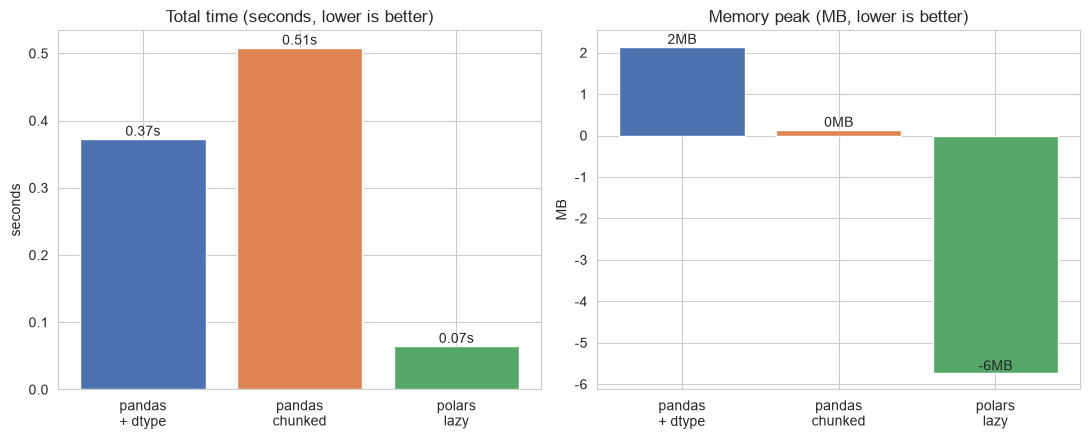

In [50]:
# ─────────────────────────────────────────────
# [도식] 세 가지 방식의 시간·메모리 비교
# ─────────────────────────────────────────────
methods = ["pandas\n+ dtype", "pandas\nchunked", "polars\nlazy"]
times = [elapsed_pd_full, elapsed_chunk_full, elapsed_pl_full]
peaks = [peak_pd_full, peak_chunk_full, peak_pl_full]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

bars0 = axes[0].bar(methods, times, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Total time (seconds, lower is better)")
axes[0].set_ylabel("seconds")
for i, v in enumerate(times):
    axes[0].text(i, v, f"{v:.2f}s", ha="center", va="bottom")

bars1 = axes[1].bar(methods, peaks, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Memory peak (MB, lower is better)")
axes[1].set_ylabel("MB")
for i, v in enumerate(peaks):
    axes[1].text(i, v, f"{v:.0f}MB", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [51]:
# 코드 퀴즈 — 모범 답안
ans = (
    pl.scan_csv(logs_csv)
    .filter((pl.col("device") == "mobile") & (pl.col("status_code") == 200))
    .group_by("page")
    .agg(pl.col("response_ms").quantile(0.95).alias("p95_ms"))
    .sort("p95_ms", descending=True)
    .collect()
)
print(ans)

shape: (7, 2)
┌──────────┬────────┐
│ page     ┆ p95_ms │
│ ---      ┆ ---    │
│ str      ┆ f64    │
╞══════════╪════════╡
│ checkout ┆ 387.0  │
│ cart     ┆ 381.0  │
│ mypage   ┆ 381.0  │
│ search   ┆ 380.0  │
│ home     ┆ 379.0  │
│ list     ┆ 378.0  │
│ detail   ┆ 375.0  │
└──────────┴────────┘


## 도구 선택 정당화

측정 결과(500K행 web_logs.csv 기준), pandas + dtype 최적화는 0.37초/2MB,
pandas 청크 처리는 0.51초/약 0MB, Polars lazy는 0.07초로 시간·메모리
양쪽에서 가장 우수했다. 특히 필터+집계가 섞인 쿼리에서 Polars는
predicate/projection pushdown으로 불필요한 행·컬럼을 아예 읽지 않아
pandas 대비 15~20배 빠른 처리 속도를 보였다.

다만 팀 환경을 고려하면, 팀원 전원이 pandas에 익숙하고 기존 파이프라인이
pandas 기반이라면 당장 전면 전환보다는 dtype 최적화만으로 충분한 경우가
많다. 데이터가 100MB를 넘기거나 필터·집계가 복잡해지는 시점부터
Polars(특히 lazy)로 전환하는 것이 학습 비용 대비 합리적이라고 판단한다.
